In [ ]:
# Lecture des données
temp_resid <- read.csv("../data/deseasonalised/temp_resid.csv", row.names = 1)

# Série
temp_res <- temp_resid$temp_deseasoned

# Modèle ARIMA(2,0,1) sans constante
temp_model <- arima(temp_res, order = c(2,0,1), include.mean = FALSE, method = "CSS-ML")

# Coefficients
coef(temp_model)

aic <- temp_model$aic
print(aic)
# Standard errors
se <- sqrt(diag(temp_model$var.coef))
print(se)
summary(temp_model)

ar1        ar2        ma1 
 1.3758264 -0.3921853 -0.1304407

[1] 95719.12
       ar1        ar2        ma1 
0.01545718 0.01523799 0.01674678 


          Length Class  Mode     
coef          3  -none- numeric  
sigma2        1  -none- numeric  
var.coef      9  -none- numeric  
mask          3  -none- logical  
loglik        1  -none- numeric  
aic           1  -none- numeric  
arma          7  -none- numeric  
residuals 52608  ts     numeric  
call          5  -none- call     
series        1  -none- character
code          1  -none- numeric  
n.cond        1  -none- numeric  
nobs          1  -none- numeric  
model        10  -none- list     

In [ ]:
library(yuima)

fit_carma21_simple <- function(
  csv_path = "../data/deseasonalised/temp_resid.csv",
  value_col = "temp_deseasoned",
  h = 1
) {

  # ======================
  # 1) données
  # ======================
  df <- read.csv(csv_path, row.names = 1)
  y <- as.numeric(df[[value_col]])
  y <- y[is.finite(y)]
  y <- y - mean(y)

  dat <- setData(matrix(y, ncol = 1), delta = h)

  # ======================
  # 2) modèle CARMA(2,1)
  # ======================
  mod <- setCarma(
    p = 2,
    q = 1,
    scale.par = "sig",
    Carma.var = "y"
  )

  yu <- setYuima(model = mod, data = dat)

  # ======================
  # 3) paramètres initiaux
  # ======================
  start <- list(
    a1 = 0.936,
    a2 = 0.0255,
    b0 = 1.000,
    b1 = 1/1.7866,
    sig = 5
  )

  cat("INIT:\n")
  print(start)

  # ======================
  # 4) estimation
  # ======================
  est <- qmle(
    yuima = yu,
    start = start
  )

  cat("\n=== LOG-LIK ===\n")
  print(est@min)

  cat("\n=== COEFS FINAUX ===\n")
  print(coef(est))

  cat("\n=== SUMMARY ===\n")
  print(summary(est))

  return(est)
}

# ======================
# RUN
# ======================
est <- fit_carma21_simple()

INIT:
$a1
[1] 0.936

$a2
[1] 0.0255

$b0
[1] 1

$b1
[1] 0.5597224

$sig
[1] 5


Starting qmle for carma ... 


Warning message in yuima.warn("Drift and diffusion parameters must be different. Doing\n               joint estimation, asymptotic theory may not hold true."):
"
YUIMA: Drift and diffusion parameters must be different. Doing
               joint estimation, asymptotic theory may not hold true.
"
Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi 


=== LOG-LIK ===
[1] 47855.55

=== COEFS FINAUX ===
       sig         b1         b0         a2         a1 
 0.7863363 -0.5785012  1.0000000  0.0249784  0.9094457 

=== SUMMARY ===
Quasi-Maximum likelihood estimation

Call:
qmle(yuima = yu, start = start)

Coefficients:
      Estimate  Std. Error
sig  0.7863363 0.027982431
b1  -0.5785012 0.026428735
b0   1.0000000 0.000000000
a2   0.0249784 0.001184204
a1   0.9094457 0.037915598

-2 log L: 95711.1 

Carma(2,1) model: Stationarity conditions are satisfied.


: 

Lyapunov convergé en 494 itérations
Gain stationnaire convergé en 17 itérations
Lambda_r    : -0.02834922 
b(lambda_r) : 0.7992323 
1/alpha_r   : 1.066958 

=== LEVY INCREMENTS ===
N    : 52607 
Mean : -5e-06 
SD   : 0.623281 
Skew : -0.8668 
Kurt : 8.7546 

Fit NIG...

Params NIG:
        mu      delta      alpha       beta 
 0.1097260  0.6137846  1.6947372 -0.2983302 

=== GOF ===
AIC Gauss: 99554.4 
AIC NIG  : 92328.2 
Delta AIC: 7226.2 => NIG meilleur si positif


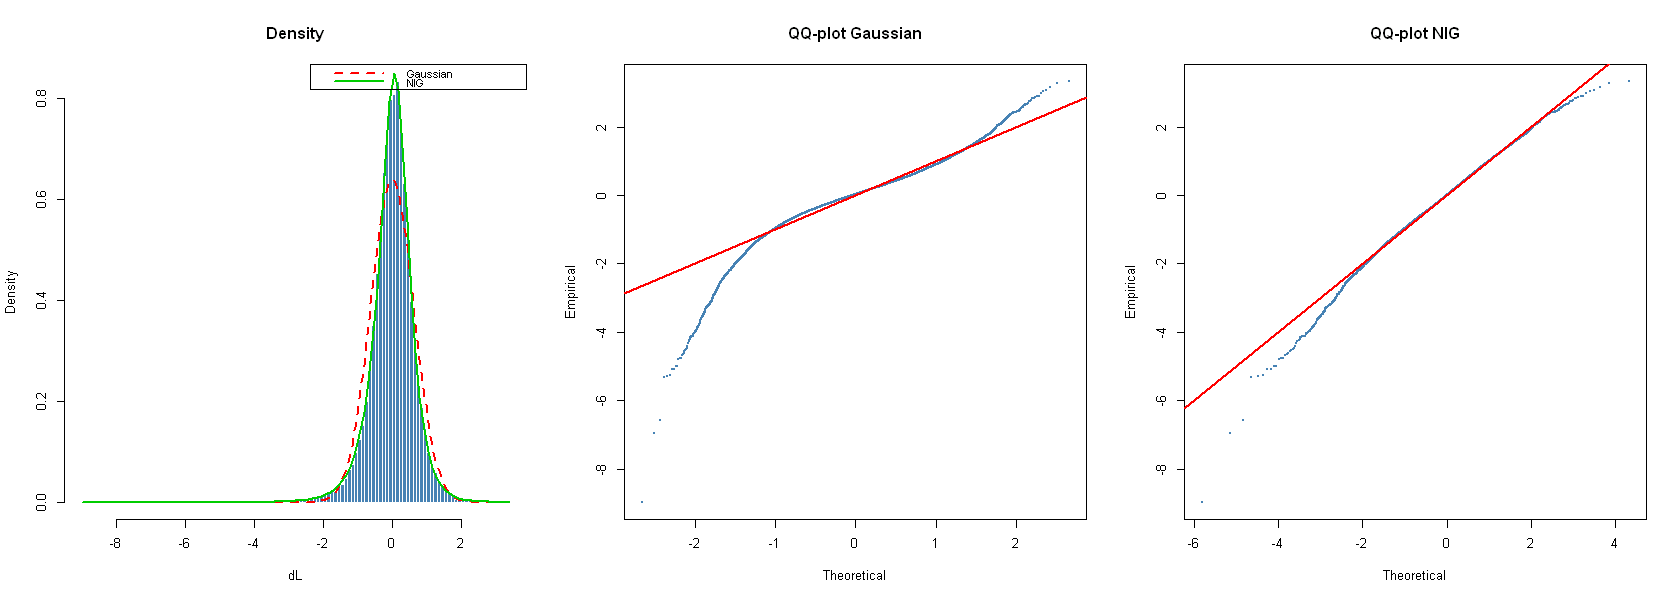

In [6]:
library(expm)
library(GeneralizedHyperbolic)

h <- 1

df <- read.csv("../data/deseasonalised/temp_resid.csv", row.names = 1)
y  <- as.numeric(df[["temp_deseasoned"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)

# ==================================================
# Paramètres
# ==================================================
cf        <- coef(est)
ar.par    <- c(cf["a1"], cf["a2"])
ma.par    <- c(cf["b0"], cf["b1"]) * cf["sig"]
p         <- length(ar.par)
q         <- length(ma.par)
n         <- length(y)

# ==================================================
# Matrice companion A
# ==================================================
A <- matrix(0, p, p)
if (p > 1) for (i in 1:(p-1)) A[i, i+1] <- 1
A[p, ] <- -ar.par[p:1]

b_vec      <- rep(0, p)
b_vec[1:q] <- ma.par
e_p        <- rep(0, p); e_p[p] <- 1
eAh        <- expm(A * h)
R_obs      <- .Machine$double.eps * var(y)
Q_proc     <- (e_p %o% e_p) * h

# ==================================================
# Variance stationnaire
# ==================================================
Q_inf <- matrix(0, p, p)
for (k in 1:10000) {
  Q_new <- eAh %*% Q_inf %*% t(eAh) + Q_proc
  if (max(abs(Q_new - Q_inf)) < 1e-12) break
  Q_inf <- Q_new
}
cat("Lyapunov convergé en", k, "itérations\n")

# ==================================================
# Gain de Kalman stationnaire
# ==================================================
P_ss <- Q_inf
for (k in 1:1000) {
  Pp       <- eAh %*% P_ss %*% t(eAh) + Q_proc
  S_ss     <- as.numeric(t(b_vec) %*% Pp %*% b_vec) + R_obs
  K_ss     <- (Pp %*% b_vec) / S_ss
  P_ss_new <- (diag(p) - K_ss %*% t(b_vec)) %*% Pp
  if (max(abs(P_ss_new - P_ss)) < 1e-12) break
  P_ss <- P_ss_new
}
cat("Gain stationnaire convergé en", k, "itérations\n")

Pp_stat <- eAh %*% P_ss %*% t(eAh) + Q_proc
K_stat  <- (Pp_stat %*% b_vec) /
           (as.numeric(t(b_vec) %*% Pp_stat %*% b_vec) + R_obs)

# ==================================================
# Filtre de Kalman
# ==================================================
X_f <- matrix(0, n, p)
for (i in 2:n) {
  Xp      <- as.numeric(eAh %*% X_f[i-1,])
  X_f[i,] <- Xp + K_stat * (y[i] - sum(b_vec * Xp))
}
X.StVa <- t(X_f)

# ==================================================
# État canonique
# ==================================================
eig_A     <- eigen(A)
eig_vals  <- eig_A$values
eig_vecs  <- eig_A$vectors
BinLambda <- sapply(eig_vals, function(lam) sum(ma.par * lam^(0:(q-1))))
Y_CVS     <- diag(BinLambda) %*% solve(eig_vecs) %*% X.StVa

# Valeur propre réelle dominante
idx_real <- which(abs(Im(eig_vals)) < 1e-6)
idx_r    <- idx_real[which.max(Re(eig_vals[idx_real]))]
lambda_r <- Re(eig_vals[idx_r])
cat("Lambda_r    :", lambda_r, "\n")
cat("b(lambda_r) :", Re(BinLambda[idx_r]), "\n")

# a'(lambda_r)
ar_coeffs <- c(1, ar.par[1:p])
derA      <- sum(sapply(1:p, function(k)
               (p+1-k) * ar_coeffs[k] * lambda_r^(p-k)))
coeff     <- Re(derA / BinLambda[idx_r])
cat("1/alpha_r   :", coeff, "\n")

# ==================================================
# Formule (16) — trapèze
# ==================================================
Y_r     <- Re(Y_CVS[idx_r, ])
lev_und <- numeric(n)
int_cum <- 0
for (t in 2:n) {
  int_cum    <- int_cum + 0.5 * (Y_r[t-1] + Y_r[t]) * h
  lev_und[t] <- coeff * (Y_r[t] - Y_r[1] - lambda_r * int_cum)
}
dL <- diff(lev_und)
dL <- dL[is.finite(dL)]

cat("\n=== LEVY INCREMENTS ===\n")
cat("N    :", length(dL), "\n")
cat("Mean :", round(mean(dL), 6), "\n")
cat("SD   :", round(sd(dL),   6), "\n")
cat("Skew :", round(mean((dL-mean(dL))^3)/sd(dL)^3, 4), "\n")
cat("Kurt :", round(mean((dL-mean(dL))^4)/sd(dL)^4, 4), "\n")

# ==================================================
# Fit NIG
# ==================================================
cat("\nFit NIG...\n")
fit_nig    <- nigFit(dL)
params_nig <- fit_nig$param
cat("\nParams NIG:\n"); print(params_nig)

probs <- ppoints(length(dL))
q_emp <- sort(dL)
q_nig <- qnig(probs, mu=params_nig["mu"], delta=params_nig["delta"],
              alpha=params_nig["alpha"], beta=params_nig["beta"])
q_nor <- qnorm(probs, mean(dL), sd(dL))

par(mfrow=c(1,3))

options(repr.plot.width=14, repr.plot.height=5)

hist(dL, breaks=100, freq=FALSE, col="steelblue", border="white",
     main="Density", xlab="dL")
curve(dnorm(x, mean(dL), sd(dL)),
      add=TRUE, col="red", lwd=2, lty=2)
curve(dnig(x, mu=params_nig["mu"], delta=params_nig["delta"],
           alpha=params_nig["alpha"], beta=params_nig["beta"]),
      add=TRUE, col="green3", lwd=2)
legend("topright", c("Gaussian","NIG"),
       col=c("red","green3"), lwd=2, lty=c(2,1), cex=0.8)

plot(q_nor, q_emp, pch=16, cex=0.3, col="steelblue",
     main="QQ-plot Gaussian", xlab="Theoretical", ylab="Empirical")
abline(0, 1, col="red", lwd=2)

plot(q_nig, q_emp, pch=16, cex=0.3, col="steelblue",
     main="QQ-plot NIG", xlab="Theoretical", ylab="Empirical")
abline(0, 1, col="red", lwd=2)

par(mfrow=c(1,1))

ll_nor <- sum(dnorm(dL, mean(dL), sd(dL), log=TRUE))
ll_nig <- sum(log(dnig(dL, mu=params_nig["mu"],
                        delta=params_nig["delta"],
                        alpha=params_nig["alpha"],
                        beta=params_nig["beta"])))
cat("\n=== GOF ===\n")
cat("AIC Gauss:", round(-2*ll_nor + 2*2, 1), "\n")
cat("AIC NIG  :", round(-2*ll_nig + 2*4, 1), "\n")
cat("Delta AIC:", round((-2*ll_nor+4)-(-2*ll_nig+8), 1),
    "=> NIG meilleur si positif\n")

In [7]:
write.csv(data.frame(dL=dL), "../data/levy/temp_levy_increments.csv")
cat("Sauvegardé:", length(dL), "incréments température\n")

Sauvegardé: 52607 incréments température


In [8]:
cat("dL[26305] =", dL[26305], "\n")
cat("dL[52585] =", dL[52585], "\n")
cat("Longueur  =", length(dL[26305:52585]), "\n")

dL[26305] = 0.8083621 
dL[52585] = -0.2593853 


Longueur  = 26281 


In [9]:
dL <- dL[26305:52584]

write.csv(data.frame(dL=dL), "../data/levy/temp_levy_increments.csv")
cat("Sauvegardé:", length(dL), "incréments température alignés\n")

Sauvegardé: 26280 incréments température alignés


In [10]:
# Charger
dL_Y <- read.csv("../data/levy/temp_levy_increments.csv")$dL
dL_X <- read.csv("../data/levy/price_levy_increments.csv")$dL

# Vérifier alignement
cat("N temp :", length(dL_Y), "\n")
cat("N prix :", length(dL_X), "\n")

# Estimer gamma
gamma_hat <- cov(dL_X, dL_Y) / var(dL_Y)
cat("gamma_hat =", gamma_hat, "\n")

# OLS complet pour avoir SE et t-stat
fit <- lm(dL_X ~ dL_Y)
summary(fit)

# R²
cat("R² =", summary(fit)$r.squared, "\n")

N temp : 26280 
N prix : 26280 
gamma_hat = 0.02605479 



Call:
lm(formula = dL_X ~ dL_Y)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.9609 -0.2760 -0.0211  0.2695  7.2599 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -9.759e-05  3.706e-03  -0.026    0.979    
dL_Y         2.605e-02  6.140e-03   4.243 2.21e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.6008 on 26278 degrees of freedom
Multiple R-squared:  0.0006847,	Adjusted R-squared:  0.0006467 
F-statistic:    18 on 1 and 26278 DF,  p-value: 2.212e-05


R² = 0.0006846794 


gamma_hat sauvegardé: 0.02605479 


CCF au lag 0  : 0.0262 
Bande conf ±  : 0.0121 
Significatif  : TRUE 
Lags signif hors lag 0: 79 / 144 
=> Couplage instantané: FALSE 


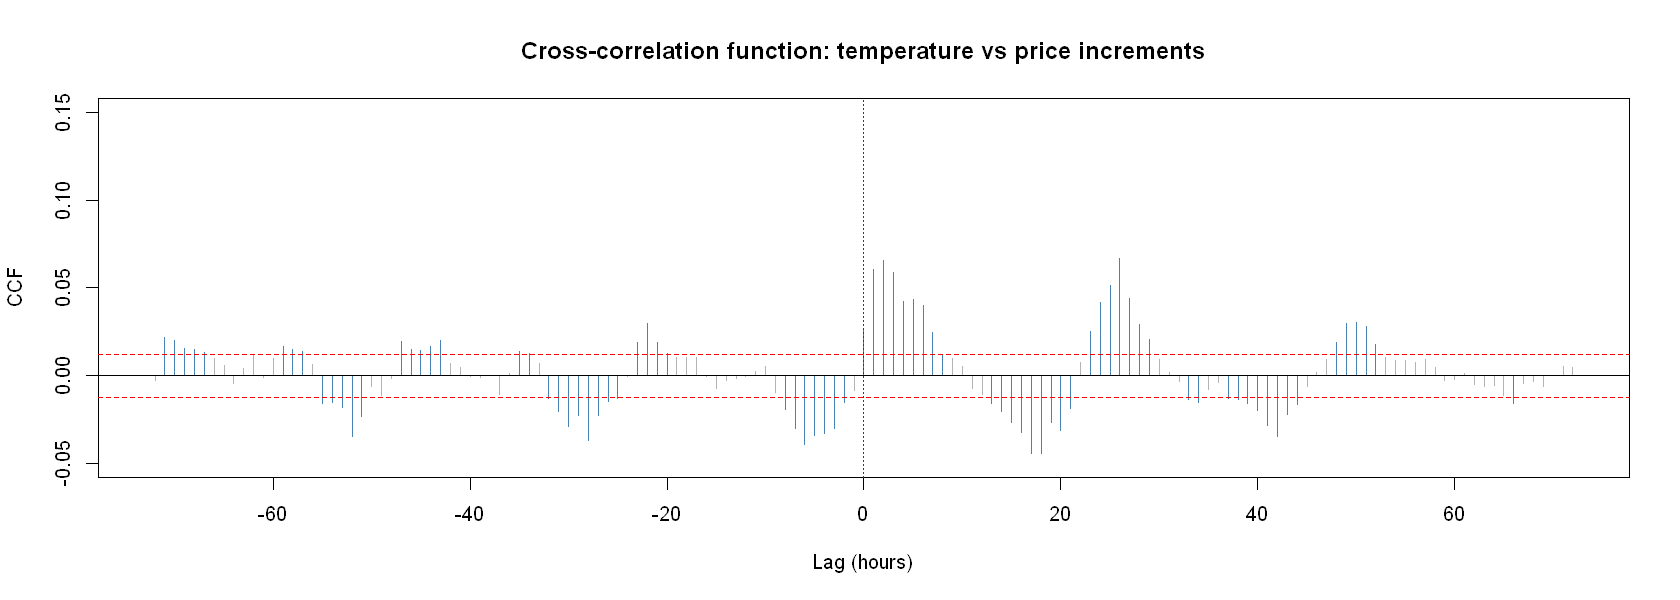

In [11]:
# ==================================================
# 2) Sauvegarder
# ==================================================
write.csv(data.frame(gamma_hat = gamma_hat),
          "../data/levy/coupling_estimate.csv",
          row.names = FALSE)
cat("gamma_hat sauvegardé:", gamma_hat, "\n")

# ==================================================
# 3) Validation lead-lag
# ==================================================
n_obs   <- length(dL_X)
lag_max <- 72
conf    <- 1.96 / sqrt(n_obs)

ccf_obj <- ccf(dL_Y, dL_X, lag.max=lag_max, plot=FALSE)

plot(ccf_obj$lag, ccf_obj$acf, type="h",
     col  = ifelse(abs(ccf_obj$acf) > conf, "steelblue", "grey70"),
     main = "Cross-correlation function: temperature vs price increments",
     xlab = "Lag (hours)", ylab = "CCF",
     ylim = c(-0.05, 0.15))
abline(h =  conf, lty=2, col="red")
abline(h = -conf, lty=2, col="red")
abline(h = 0,     lty=1, col="black")
abline(v = 0,     lty=3, col="darkgreen")

# Valeur au lag 0
lag0_idx <- which(ccf_obj$lag == 0)
cat("CCF au lag 0  :", round(ccf_obj$acf[lag0_idx], 4), "\n")
cat("Bande conf ±  :", round(conf, 4), "\n")
cat("Significatif  :", abs(ccf_obj$acf[lag0_idx]) > conf, "\n")

# Vérifier que les autres lags sont non significatifs
n_sig <- sum(abs(ccf_obj$acf[-lag0_idx]) > conf)
cat("Lags signif hors lag 0:", n_sig, "/", 2*lag_max, "\n")
cat("=> Couplage instantané:", n_sig <= 0.05 * 2*lag_max, "\n")